# Phase 6 — Training Dynamics: per-combination loss curves

Companion notebook to [`Docs/Phase6-TrainingDynamics.md`](../Docs/Phase6-TrainingDynamics.md). One annotated subplot per **learned** combination, plotting per-epoch `train_loss` and `val_loss` together. The default config trains the `season_holdout` strategy only — one fold per combination. When `loso_cv` is enabled, each combination has one fold per held-out season; those per-fold curves are drawn faint with the per-epoch fold-mean overlaid in bold (DD-TD-02).

> **Data source.** Authored against `tests/fixtures/train/expected/training_loss_curves.parquet` so the CPU-only dev box renders real curves end-to-end. After a full run populates `Data/processed/training_loss_curves.parquet`, set `USE_FIXTURE = False` in the second code cell and re-execute. The on-disk SHA is verified against `training_manifest.json` by `nflpredictor.diagnostics.loss_curves.load_loss_curves`.

In [1]:
import pathlib
import shutil
import sys
import tempfile

import matplotlib.pyplot as plt
import pandas as pd

# Locate the repo root regardless of where the kernel was started.
_here = pathlib.Path.cwd()
if (_here / "src" / "nflpredictor").is_dir():
    REPO_ROOT = _here
elif (_here.parent / "src" / "nflpredictor").is_dir():
    REPO_ROOT = _here.parent
else:
    raise RuntimeError(f"Cannot locate repo root from {_here}")
sys.path.insert(0, str(REPO_ROOT / "src"))

from nflpredictor.diagnostics import loss_curves

In [2]:
# Stage a processed_dir from the train fixture so load_loss_curves can verify
# the parquet's SHA against the fixture's training_manifest.json. Set
# USE_FIXTURE = False after the CUDA run to read Data/processed/ directly.
USE_FIXTURE = True

if USE_FIXTURE:
    TRAIN_FIXTURE = REPO_ROOT / "tests" / "fixtures" / "train"
    STAGE = pathlib.Path(tempfile.mkdtemp(prefix="phase6_training_dynamics_"))
    shutil.copy2(TRAIN_FIXTURE / "expected" / "training_loss_curves.parquet", STAGE / "training_loss_curves.parquet")
    shutil.copy2(TRAIN_FIXTURE / "expected" / "training_manifest.json", STAGE / "training_manifest.json")
    PROCESSED_DIR = STAGE
else:
    PROCESSED_DIR = REPO_ROOT / "Data" / "processed"

curves = loss_curves.load_loss_curves(processed_dir=PROCESSED_DIR)
print(f"Loaded {len(curves)} rows from {PROCESSED_DIR / 'training_loss_curves.parquet'}")
print(f"Columns: {list(curves.columns)}")
print(f"Combinations: {sorted(curves['combination_id'].unique())}")

Loaded 40 rows from /tmp/phase6_training_dynamics_2x77y7kb/training_loss_curves.parquet
Columns: ['combination_id', 'fold', 'epoch', 'train_loss', 'val_loss', 'val_mae']
Combinations: ['rung2_linear__flat__season_holdout', 'rung2_linear__pos__season_holdout', 'rung3_mlp__flat__season_holdout', 'rung3_mlp__pos__season_holdout']


## One subplot per learned combination

The default config's learned combinations: rung 2 linear (flat, pos) and rung 3 MLP (flat, pos), each trained for the `season_holdout` strategy. Each subplot:

* X axis: `epoch`.
* Y axis: per-epoch loss (L1, MAE-scaled — same units as the Phase 5 headline metric).
* Two series: `train_loss` (solid) and `val_loss` (dashed).
* `season_holdout` combinations have one fold, so one bold line per series. A `loso_cv` combination would draw faint per-fold lines plus a bold per-epoch mean.

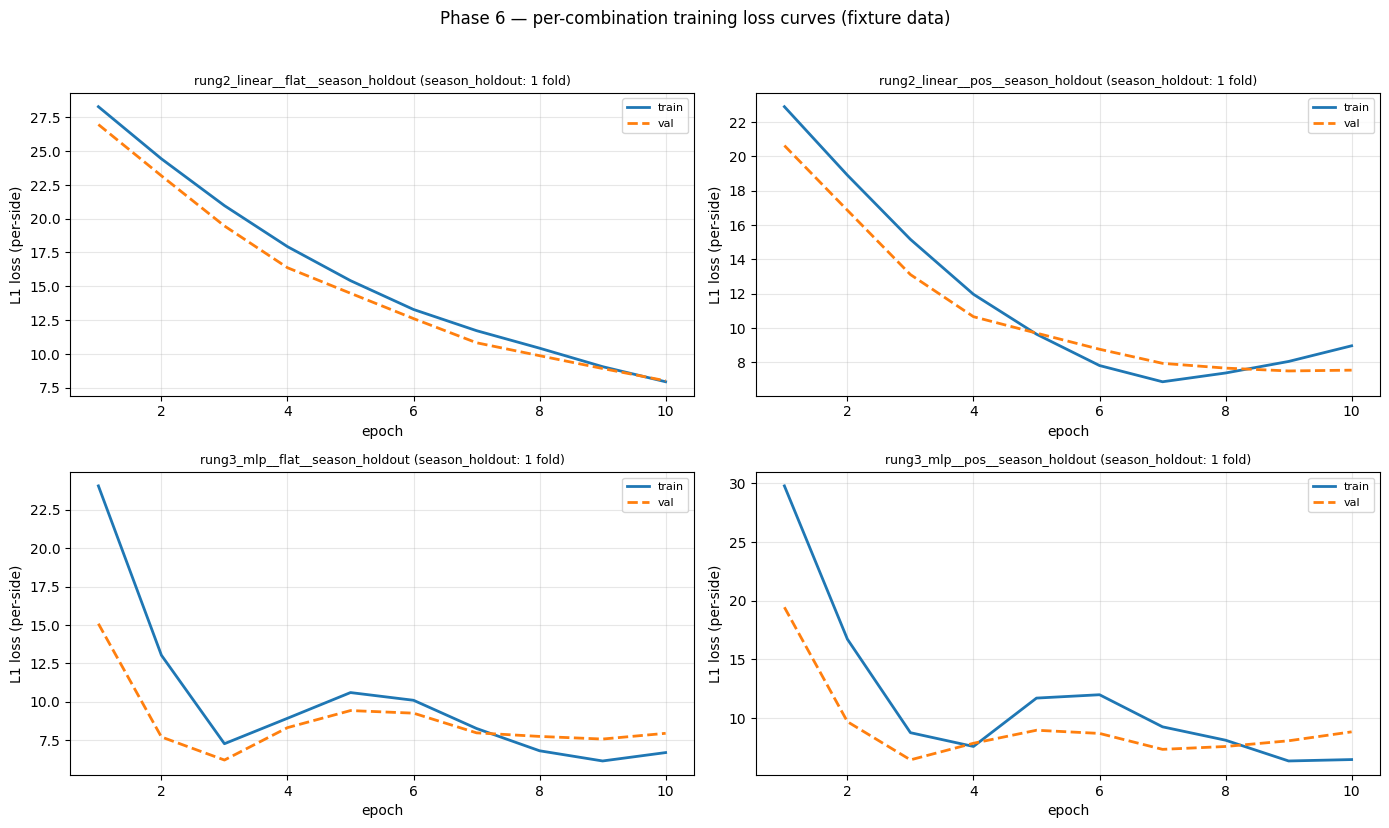

In [3]:
COMBINATIONS = sorted(curves['combination_id'].unique())

ncols = 2
nrows = (len(COMBINATIONS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows), sharey=False)
axes = axes.ravel()

for ax, combo in zip(axes, COMBINATIONS):
    sub = curves[curves['combination_id'] == combo]
    folds = sorted(sub['fold'].unique())
    is_cv = len(folds) > 1
    if is_cv:
        # loso_cv: faint per-fold lines, bold per-epoch mean.
        for fold in folds:
            fold_df = sub[sub['fold'] == fold].sort_values('epoch')
            ax.plot(fold_df['epoch'], fold_df['train_loss'], color='tab:blue', alpha=0.15)
            ax.plot(fold_df['epoch'], fold_df['val_loss'], color='tab:orange', alpha=0.15)
        mean = sub.groupby('epoch')[['train_loss', 'val_loss']].mean().reset_index()
        ax.plot(mean['epoch'], mean['train_loss'], color='tab:blue', linewidth=2.0, label='train (fold-mean)')
        ax.plot(mean['epoch'], mean['val_loss'], color='tab:orange', linewidth=2.0, linestyle='--', label='val (fold-mean)')
        ax.set_title(f"{combo}\n(loso_cv: {len(folds)} folds, faint = per-fold, bold = mean)", fontsize=9)
    else:
        only = sub.sort_values('epoch')
        ax.plot(only['epoch'], only['train_loss'], color='tab:blue', linewidth=2.0, label='train')
        ax.plot(only['epoch'], only['val_loss'], color='tab:orange', linewidth=2.0, linestyle='--', label='val')
        ax.set_title(f"{combo} (season_holdout: 1 fold)", fontsize=9)
    ax.set_xlabel('epoch')
    ax.set_ylabel('L1 loss (per-side)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

# Hide any unused axes.
for ax in axes[len(COMBINATIONS):]:
    ax.set_visible(False)

fig.suptitle('Phase 6 — per-combination training loss curves (fixture data)', fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## Annotated callout — `rung3_mlp__flat__season_holdout`

A closer look at one combination, with prose callouts pointing at notable inflections. The choice of `rung3_mlp__flat__season_holdout` is illustrative — it's the highest-capacity learned rung on the simplest feature shape, so any pattern in the curve maps cleanly back to the §5 diagnostics in [Phase6-TrainingDynamics.md](../Docs/Phase6-TrainingDynamics.md).

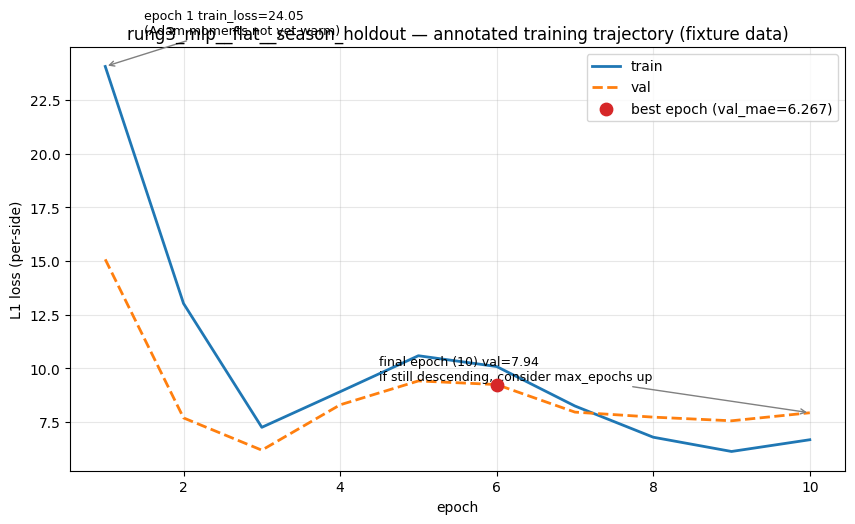


Best epoch for rung3_mlp__flat__season_holdout: epoch=6, val_mae=6.267477
Final epoch: epoch=10, val_mae=8.394106
(On a real run the 'final' value here is typically epoch 20+ post-best when early stopping fires.)


In [4]:
FOCUS_COMBO = 'rung3_mlp__flat__season_holdout'
focus = curves[curves['combination_id'] == FOCUS_COMBO].sort_values('epoch')

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(focus['epoch'], focus['train_loss'], color='tab:blue', linewidth=2.0, label='train')
ax.plot(focus['epoch'], focus['val_loss'], color='tab:orange', linewidth=2.0, linestyle='--', label='val')

# Mark the best-epoch (lowest val_mae) — the params Phase 4 actually emits.
best_idx = focus['val_mae'].idxmin()
best_row = focus.loc[best_idx]
ax.scatter([best_row['epoch']], [best_row['val_loss']], color='tab:red', zorder=5, s=80, label=f"best epoch (val_mae={best_row['val_mae']:.3f})")

# Prose callouts. On the fixture data the curves are short (10 epochs) so the
# annotations are illustrative of where one would point on a longer real run.
first_train = focus.iloc[0]
last_train = focus.iloc[-1]
ax.annotate(
    f"epoch 1 train_loss={first_train['train_loss']:.2f}\n(Adam moments not yet warm)",
    xy=(first_train['epoch'], first_train['train_loss']),
    xytext=(first_train['epoch'] + 0.5, first_train['train_loss'] + 1.5),
    fontsize=9,
    arrowprops=dict(arrowstyle='->', color='gray'),
)
ax.annotate(
    f"final epoch ({int(last_train['epoch'])}) val={last_train['val_loss']:.2f}\nif still descending, consider max_epochs up",
    xy=(last_train['epoch'], last_train['val_loss']),
    xytext=(last_train['epoch'] - 5.5, last_train['val_loss'] + 1.5),
    fontsize=9,
    arrowprops=dict(arrowstyle='->', color='gray'),
)

ax.set_xlabel('epoch')
ax.set_ylabel('L1 loss (per-side)')
ax.set_title(f'{FOCUS_COMBO} — annotated training trajectory (fixture data)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
plt.show()

print(f"\nBest epoch for {FOCUS_COMBO}: epoch={int(best_row['epoch'])}, val_mae={best_row['val_mae']:.6f}")
print(f"Final epoch: epoch={int(last_train['epoch'])}, val_mae={last_train['val_mae']:.6f}")
print("(On a real run the 'final' value here is typically epoch 20+ post-best when early stopping fires.)")